In [1]:
# Built-in
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, TimeDistributed, GlobalAveragePooling2D, LSTM, Dense, Dropout
)
from keras_cv_attention_models import mobilevit
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Scikit-learn
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)


d:\MobileLSTM-HMM-KAN\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define the path to the dataset
base_path = 'D:\MobileLSTM-HMM-KAN\dataset\\celeb'
categories = ['fake', 'real']

# Initialize a list to hold data
data = []

# Process each category
for category in categories:
    category_path = os.path.join(base_path, category)
    for filename in os.listdir(category_path):
        if filename.endswith('.jpg'):
            try:
                id_part, frame_part = filename.split('_frame_')
                id_ = id_part.split('_')[0]
                frame = frame_part.split('.')[0]
                data.append({
                    'filename': filename,
                    'path': os.path.join(category_path, filename),
                    'id': int(id_),
                    'frame': int(frame),
                    'label': category
                })
            except ValueError:
                continue

# Convert the data to a DataFrame
df = pd.DataFrame(data)

In [3]:
# Đảm bảo đã có df_cropped.csv chứa đường dẫn ảnh đã crop
df['label_id'] = df['label'].map({'fake': 0, 'real': 1})
df


,filename,path,id,frame,label,label_id
0,000_id0_0000_frame_0000.jpg,D:\MobileLSTM-HMM-KAN\dataset\celeb\fake\000_i...,0,0,fake,0
1,000_id0_0000_frame_0001.jpg,D:\MobileLSTM-HMM-KAN\dataset\celeb\fake\000_i...,0,1,fake,0
2,000_id0_0000_frame_0002.jpg,D:\MobileLSTM-HMM-KAN\dataset\celeb\fake\000_i...,0,2,fake,0
3,000_id0_0000_frame_0003.jpg,D:\MobileLSTM-HMM-KAN\dataset\celeb\fake\000_i...,0,3,fake,0
4,000_id0_0000_frame_0004.jpg,D:\MobileLSTM-HMM-KAN\dataset\celeb\fake\000_i...,0,4,fake,0
...,...,...,...,...,...,...
32367,541_id9_0009_frame_0025.jpg,D:\MobileLSTM-HMM-KAN\dataset\celeb\real\541_i...,541,25,real,1
32368,541_id9_0009_frame_0026.jpg,D:\MobileLSTM-HMM-KAN\dataset\celeb\real\541_i...,541,26,real,1
32369,541_id9_0009_frame_0027.jpg,D:\MobileLSTM-HMM-KAN\dataset\celeb\real\541_i...,541,27,real,1
32370,541_id9_0009_frame_0028.jpg,D:\MobileLSTM-HMM-KAN\dataset\celeb\real\541_i...,541,28,real,1


In [4]:
df['video_key'] = df['id'].astype(str) + "_" + df['label']

from collections import defaultdict

video_dict = defaultdict(list)
labels = {}

for _, row in df.iterrows():
    key = row['video_key']
    video_dict[key].append(row['path'])
    labels[key] = row['label_id']


In [ ]:
# Chuẩn bị dữ liệu
video_keys = list(video_dict.keys())
video_labels = [labels[k] for k in video_keys]

# Cấu hình
img_size = (224, 224)
batch_size = 32
epochs = 50
n_splits = 5
sequence_len = 10
results = []
all_histories = []

# Custom data generator để nạp chuỗi ảnh từ video_dict
class VideoSequence(tf.keras.utils.Sequence):
    def __init__(self, video_keys, video_dict, labels, batch_size, img_size, sequence_len=10, augment=False):
        self.video_keys = video_keys
        self.video_dict = video_dict
        self.labels = labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.sequence_len = sequence_len
        self.augment = augment
        self.datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=15 if augment else 0,
            zoom_range=0.1 if augment else 0,
            horizontal_flip=augment
        )

    def __len__(self):
        return int(np.ceil(len(self.video_keys) / self.batch_size))

    def __getitem__(self, idx):
        batch_keys = self.video_keys[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_X, batch_y = [], []

        for key in batch_keys:
            frames = video_dict[key][:self.sequence_len]
            imgs = []
            for path in frames:
                img = cv2.imread(path)
                img = cv2.resize(img, self.img_size)
                img = self.datagen.random_transform(img) if self.augment else img
                img = img.astype('float32') / 255.0
                imgs.append(img)
            while len(imgs) < self.sequence_len:
                imgs.append(np.zeros((*self.img_size, 3), dtype='float32'))  # padding
            batch_X.append(imgs)
            batch_y.append(self.labels[key])

        return np.array(batch_X), np.array(batch_y)

# Hàm xây dựng mô hình
def build_model(sequence_len, img_size):
    base_model = mobilevit.MobileViT_V2_100(input_shape=(*img_size, 3), pretrained="imagenet", num_classes=0)

    # Freeze toàn bộ backbone để giảm overfit
    base_model.trainable = False

    # CNN feature extractor
    model_out = GlobalAveragePooling2D()(base_model.output)
    model = Model(inputs=base_model.input, outputs=model_out)

    # Sequence input
    input_seq = Input(shape=(sequence_len, *img_size, 3))
    x = TimeDistributed(model)(input_seq)

    # LSTM đơn giản hơn
    x = LSTM(64, return_sequences=False)(x)
    x = Dropout(0.5)(x)

    # Không dùng nhiều Dense, chỉ một đầu ra
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=input_seq, outputs=output)
    return model

# K-Fold huấn luyện
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (trainval_idx, test_idx) in enumerate(skf.split(video_keys, video_labels), 1):
    print(f"\n===== Fold {fold} =====")

    trainval_keys = [video_keys[i] for i in trainval_idx]
    test_keys = [video_keys[i] for i in test_idx]

    y_trainval = [labels[k] for k in trainval_keys]
    train_keys, val_keys = train_test_split(trainval_keys, test_size=0.1, stratify=y_trainval, random_state=fold)

    train_gen = VideoSequence(train_keys, video_dict, labels, batch_size, img_size, sequence_len, augment=True)
    val_gen   = VideoSequence(val_keys, video_dict, labels, batch_size, img_size, sequence_len, augment=False)
    test_gen  = VideoSequence(test_keys, video_dict, labels, batch_size, img_size, sequence_len, augment=False)

    model = build_model(sequence_len, img_size)
    model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay= 5e-5), loss='binary_crossentropy', metrics=['accuracy'])

    model_path = f"best_model_fold{fold}.h5"
    checkpoint = ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
    earlystop = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

    history = model.fit(train_gen, validation_data=val_gen,
                        epochs=epochs, callbacks=[checkpoint, earlystop, reduce_lr], verbose=1)

    all_histories.append(history.history)

    model.load_weights(model_path)

    y_true = [labels[k] for k in test_keys]
    y_pred_prob = model.predict(test_gen).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)

    results.append({
        'fold': fold,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'auc': roc_auc_score(y_true, y_pred_prob)
    })

# Tổng kết kết quả
print("\n📊 Tổng kết kết quả các fold:")
for r in results:
    print(f"Fold {r['fold']}: Accuracy={r['accuracy']:.4f}, F1={r['f1']:.4f}, AUC={r['auc']:.4f}")



===== Fold 1 =====


>>>> Load pretrained from: C:\Users\haida_n7tb2yf\.keras\models\mobilevit_v2_050_256_imagenet.h5
Epoch 1/50


49/49 [==============================] - ETA: 0s - loss: 0.7091 - accuracy: 0.4910
Epoch 1: val_accuracy improved from -inf to 0.50575, saving model to best_model_fold1.h5


d:\MobileLSTM-HMM-KAN\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


49/49 [==============================] - 281s 5s/step - loss: 0.7091 - accuracy: 0.4910 - val_loss: 0.7024 - val_accuracy: 0.5057 - lr: 1.0000e-04
Epoch 2/50
49/49 [==============================] - ETA: 0s - loss: 0.6991 - accuracy: 0.5205
Epoch 2: val_accuracy improved from 0.50575 to 0.51724, saving model to best_model_fold1.h5
49/49 [==============================] - 105s 2s/step - loss: 0.6991 - accuracy: 0.5205 - val_loss: 0.6979 - val_accuracy: 0.5172 - lr: 1.0000e-04
Epoch 3/50
49/49 [==============================] - ETA: 0s - loss: 0.6944 - accuracy: 0.5192
Epoch 3: val_accuracy improved from 0.51724 to 0.55172, saving model to best_model_fold1.h5
49/49 [==============================] - 108s 2s/step - loss: 0.6944 - accuracy: 0.5192 - val_loss: 0.6951 - val_accuracy: 0.5517 - lr: 1.0000e-04
Epoch 4/50
49/49 [==============================] - ETA: 0s - loss: 0.6951 - accuracy: 0.5308
Epoch 4: val_accuracy did not improve from 0.55172
49/49 [==============================] - 1

d:\MobileLSTM-HMM-KAN\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 2/50
49/49 [==============================] - ETA: 0s - loss: 0.6877 - accuracy: 0.5462
Epoch 2: val_accuracy did not improve from 0.54023
49/49 [==============================] - 105s 2s/step - loss: 0.6877 - accuracy: 0.5462 - val_loss: 0.6858 - val_accuracy: 0.5287 - lr: 1.0000e-04
Epoch 3/50
49/49 [==============================] - ETA: 0s - loss: 0.6866 - accuracy: 0.5423
Epoch 3: val_accuracy improved from 0.54023 to 0.55172, saving model to best_model_fold2.h5
49/49 [==============================] - 104s 2s/step - loss: 0.6866 - accuracy: 0.5423 - val_loss: 0.6838 - val_accuracy: 0.5517 - lr: 1.0000e-04
Epoch 4/50
49/49 [==============================] - ETA: 0s - loss: 0.6872 - accuracy: 0.5308
Epoch 4: val_accuracy improved from 0.55172 to 0.56322, saving model to best_model_fold2.h5
49/49 [==============================] - 105s 2s/step - loss: 0.6872 - accuracy: 0.5308 - val_loss: 0.6824 - val_accuracy: 0.5632 - lr: 1.0000e-04
Epoch 5/50
49/49 [========================

...

49/49 [==============================] - 229s 4s/step - loss: 0.6957 - accuracy: 0.5436 - val_loss: 0.6922 - val_accuracy: 0.5402 - lr: 1.0000e-04
Epoch 2/50
49/49 [==============================] - ETA: 0s - loss: 0.7016 - accuracy: 0.5128
Epoch 2: val_accuracy did not improve from 0.54023
49/49 [==============================] - 115s 2s/step - loss: 0.7016 - accuracy: 0.5128 - val_loss: 0.6896 - val_accuracy: 0.5287 - lr: 1.0000e-04
Epoch 3/50
49/49 [==============================] - ETA: 0s - loss: 0.6966 - accuracy: 0.5179
Epoch 3: val_accuracy did not improve from 0.54023
49/49 [==============================] - 115s 2s/step - loss: 0.6966 - accuracy: 0.5179 - val_loss: 0.6878 - val_accuracy: 0.5287 - lr: 1.0000e-04
Epoch 4/50
49/49 [==============================] - ETA: 0s - loss: 0.6928 - accuracy: 0.5167
Epoch 4: val_accuracy did not improve from 0.54023
49/49 [==============================] - 129s 3s/step - loss: 0.6928 - accuracy: 0.5167 - val_loss: 0.6860 - val_accuracy: 0

d:\MobileLSTM-HMM-KAN\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


49/49 [==============================] - 169s 3s/step - loss: 0.7049 - accuracy: 0.5115 - val_loss: 0.6988 - val_accuracy: 0.4483 - lr: 1.0000e-04
Epoch 2/50
49/49 [==============================] - ETA: 0s - loss: 0.7017 - accuracy: 0.5000
Epoch 2: val_accuracy did not improve from 0.44828
49/49 [==============================] - 127s 3s/step - loss: 0.7017 - accuracy: 0.5000 - val_loss: 0.6950 - val_accuracy: 0.4253 - lr: 1.0000e-04
Epoch 3/50
49/49 [==============================] - ETA: 0s - loss: 0.7016 - accuracy: 0.4885
Epoch 3: val_accuracy improved from 0.44828 to 0.48276, saving model to best_model_fold4.h5
49/49 [==============================] - 129s 3s/step - loss: 0.7016 - accuracy: 0.4885 - val_loss: 0.6920 - val_accuracy: 0.4828 - lr: 1.0000e-04
Epoch 4/50
49/49 [==============================] - ETA: 0s - loss: 0.6877 - accuracy: 0.5372
Epoch 4: val_accuracy improved from 0.48276 to 0.56322, saving model to best_model_fold4.h5
49/49 [==============================] - 1

d:\MobileLSTM-HMM-KAN\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


49/49 [==============================] - 160s 3s/step - loss: 0.6889 - accuracy: 0.5429 - val_loss: 0.6932 - val_accuracy: 0.5057 - lr: 1.0000e-04
Epoch 2/50
49/49 [==============================] - ETA: 0s - loss: 0.6878 - accuracy: 0.5493
Epoch 2: val_accuracy did not improve from 0.50575
49/49 [==============================] - 122s 2s/step - loss: 0.6878 - accuracy: 0.5493 - val_loss: 0.6916 - val_accuracy: 0.4828 - lr: 1.0000e-04
Epoch 3/50
49/49 [==============================] - ETA: 0s - loss: 0.6878 - accuracy: 0.5480
Epoch 3: val_accuracy did not improve from 0.50575
49/49 [==============================] - 119s 2s/step - loss: 0.6878 - accuracy: 0.5480 - val_loss: 0.6897 - val_accuracy: 0.4943 - lr: 1.0000e-04
Epoch 4/50
49/49 [==============================] - ETA: 0s - loss: 0.6806 - accuracy: 0.5583
Epoch 4: val_accuracy improved from 0.50575 to 0.51724, saving model to best_model_fold5.h5
49/49 [==============================] - 117s 2s/step - loss: 0.6806 - accuracy: 0.

In [8]:
results_df = pd.DataFrame(results)
print("📊 Kết quả trung bình:")
print(results_df.mean(numeric_only=True))
results_df


📊 Kết quả trung bình:
fold         3.000000
accuracy     0.564555
precision    0.562769
recall       0.505878
f1           0.521922
auc          0.578871
dtype: float64


,fold,accuracy,precision,recall,f1,auc
0,1,0.599078,0.606061,0.555556,0.579710,0.613744
1,2,0.608295,0.618557,0.555556,0.585366,0.663609
2,3,0.483871,0.466667,0.192661,0.272727,0.419810
3,4,0.589862,0.584746,0.633028,0.607930,0.620116
4,5,0.541667,0.537815,0.592593,0.563877,0.577075


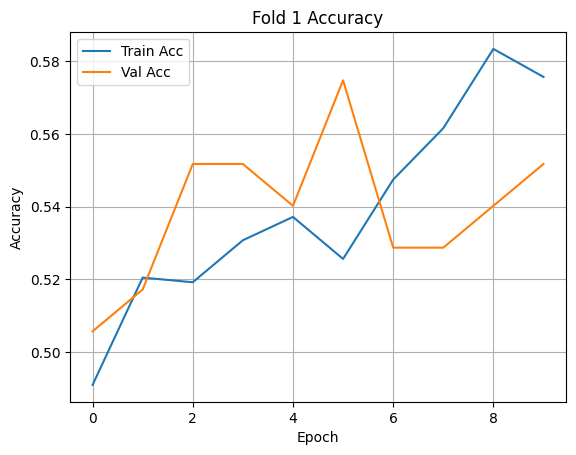

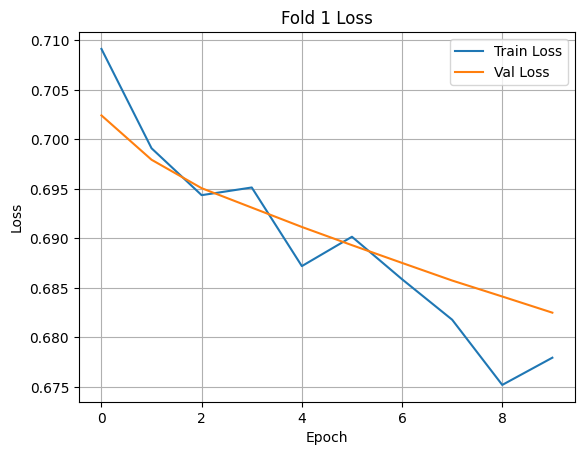

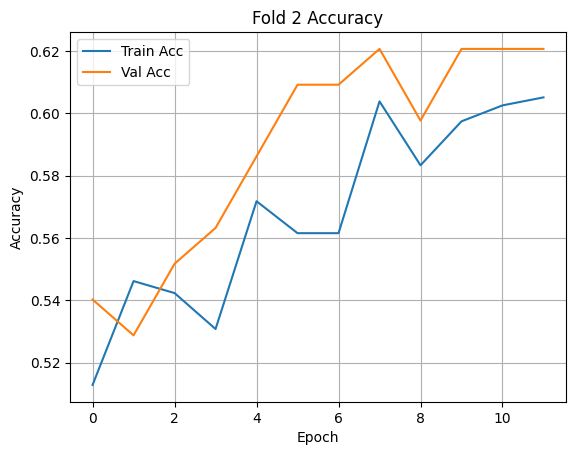

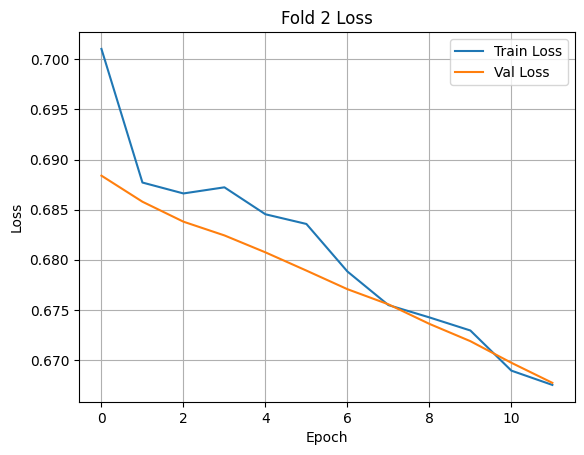

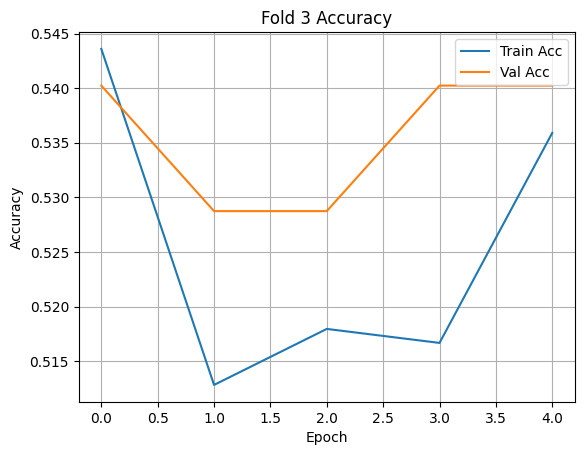

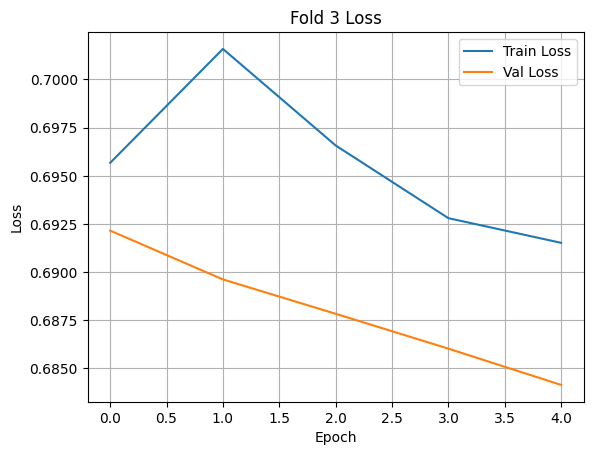

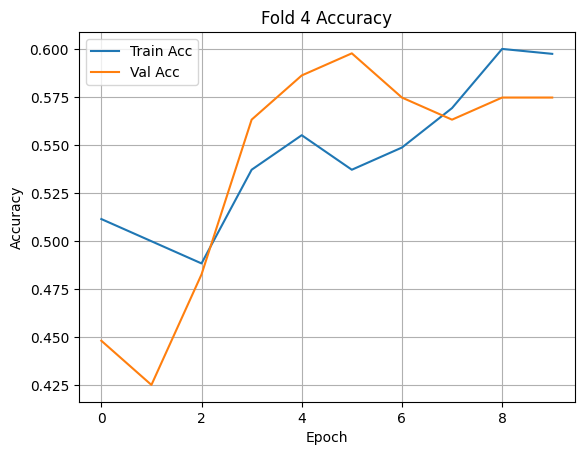

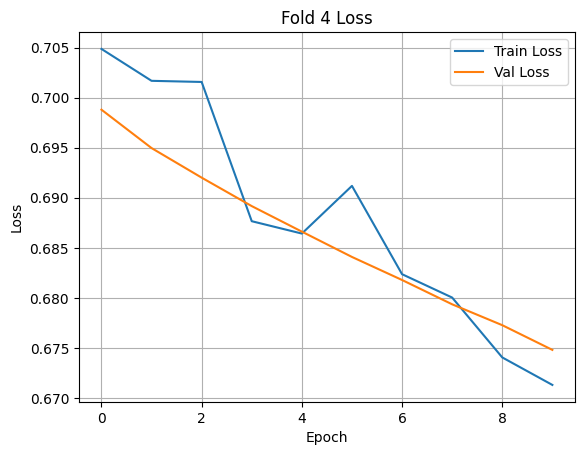

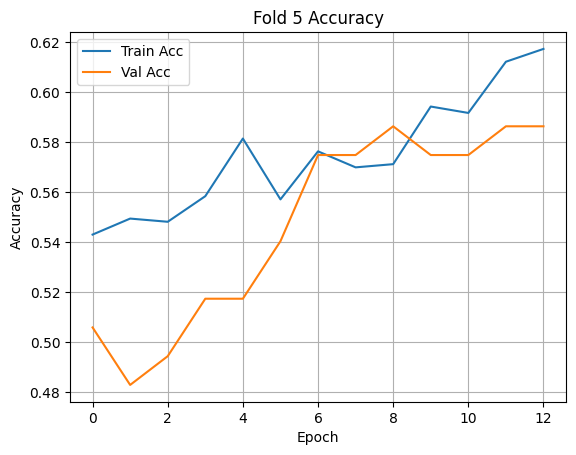

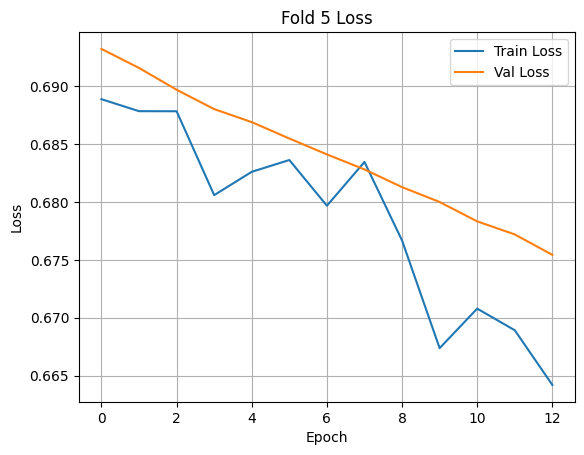

In [9]:
for i, hist in enumerate(all_histories, 1):
    plt.figure()
    plt.plot(hist['accuracy'], label='Train Acc')
    plt.plot(hist['val_accuracy'], label='Val Acc')
    plt.title(f'Fold {i} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(hist['loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Val Loss')
    plt.title(f'Fold {i} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


In [11]:
import pandas as pd

# Giả sử results đã có và bạn đã tạo results_df
results_df = pd.DataFrame(results)

# Tính các chỉ số
accuracy_mean = results_df['accuracy'].mean()
accuracy_std = results_df['accuracy'].std()  # dùng sample std (chia cho n-1)
accuracy_range = results_df['accuracy'].max() - results_df['accuracy'].min()
accuracy_cv_percent = (accuracy_std / accuracy_mean) * 100

# In kết quả
print("📊 Kết quả trung bình:")
print(results_df.mean(numeric_only=True))

print(f"\n✅ CV Accuracy (Mean Accuracy): {accuracy_mean:.4f}")
print(f"📈 Range Accuracy: {accuracy_range:.4f}")
print(f"📉 Accuracy CV% (std/mean): {accuracy_cv_percent:.2f}%")

# Hiển thị bảng kết quả nếu cần
results_df


📊 Kết quả trung bình:
fold         3.000000
accuracy     0.564555
precision    0.562769
recall       0.505878
f1           0.521922
auc          0.578871
dtype: float64

✅ CV Accuracy (Mean Accuracy): 0.5646
📈 Range Accuracy: 0.1244
📉 Accuracy CV% (std/mean): 9.20%


,fold,accuracy,precision,recall,f1,auc
0,1,0.599078,0.606061,0.555556,0.579710,0.613744
1,2,0.608295,0.618557,0.555556,0.585366,0.663609
2,3,0.483871,0.466667,0.192661,0.272727,0.419810
3,4,0.589862,0.584746,0.633028,0.607930,0.620116
4,5,0.541667,0.537815,0.592593,0.563877,0.577075
